In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def normalizeaza(date):
    media = np.mean(date)
    deviatia = np.std(date)
    if deviatia == 0:
        return date, media, deviatia
    normalizata = (date - media) / deviatia
    return normalizata, media, deviatia

def denormalizeaza(normalizata, media, deviatia):
    if deviatia == 0:
        return normalizata
    return normalizata * deviatia + media

def antreneaza_batch_gd(X, Y, learning_rate=0.01, epoci = 1000):
    n = len(Y)
    w = 0.0
    b = 0.0 

    istoric_eroare = []
    for epoch in range(epoci):
        y_pred = w * X + b
        mse = np.mean((Y - y_pred) ** 2)
        istoric_eroare.append(mse)
        eroare = Y - y_pred
        gradient_w = -(2/n) * np.dot(X, eroare)
        gradient_b = -(2/n) * np.sum(eroare)
        w -= learning_rate * gradient_w
        b -= learning_rate * gradient_b

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, MSE: {mse}")
    return w, b, istoric_eroare

def normalizeaza_multi(X):
    media = np.mean(X, axis=0)
    deviatia = np.std(X, axis=0)
    if np.any(deviatia == 0):
        return X, media, deviatia
    normalizata = (X - media) / deviatia
    return normalizata, media, deviatia

def antreneaza_batch_gd_universal(X, Y, learning_rate = 0.01, epoci = 1000, usa_mae=False):
    n, m = X.shape

    X_bias = np.column_stack((np.ones(n), X))

    W = np.zeros(m + 1)

    istoric_eroare = []
    for epoch in range(epoci):
        y_pred = np.dot(X_bias, W)
        eroare = y_pred - Y
        if usa_mae:
            err = np.mean(np.abs(eroare))
            gradient = (1/n) * np.dot(X_bias.T, np.sign(eroare))
        else:
            err = np.mean((eroare) ** 2)
            gradient = (2/n) * np.dot(X_bias.T, eroare)
            
        istoric_eroare.append(err)
        W -= learning_rate * gradient

    return W, istoric_eroare


Epoch 0, MSE: 29.936948768548156
Epoch 100, MSE: 0.9510793826716978
Epoch 200, MSE: 0.44127745959248377
Epoch 300, MSE: 0.4323110905898723
Epoch 400, MSE: 0.4321533905706073
Epoch 500, MSE: 0.43215061695108864
Epoch 600, MSE: 0.43215056816881675
Epoch 700, MSE: 0.4321505673108367
Epoch 800, MSE: 0.43215056729574647
Epoch 900, MSE: 0.4321505672954811
Rezultat final: w = 0.9161194989879298, b = 5.354019346763286


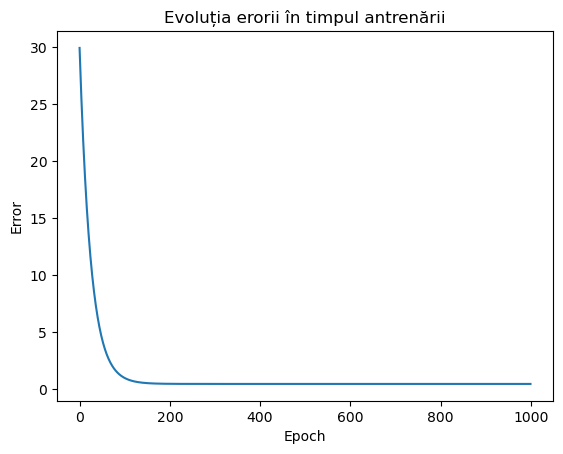

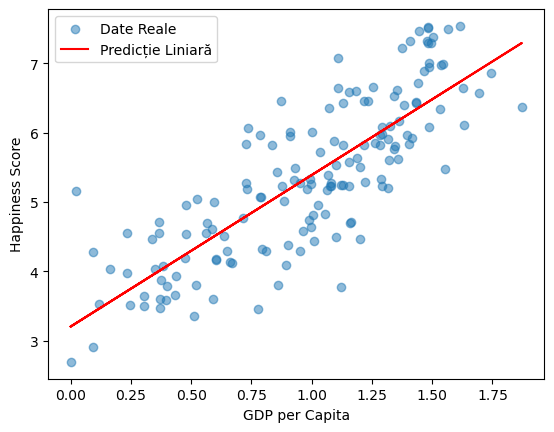

In [20]:
df = pd.read_csv("resources/2017.csv")
col_gdp = "Economy..GDP.per.Capita."
col_freedom = "Freedom"
col_happiness = "Happiness.Score"

X_raw = df[col_gdp].values
Y = df[col_happiness].values

X_norm, media_x, std_x = normalizeaza(X_raw)
W, b, istoric_eroare = antreneaza_batch_gd(X_norm, Y)

print(f"Rezultat final: w = {W}, b = {b}")

plt.plot(istoric_eroare)
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.title("Evoluția erorii în timpul antrenării")
plt.show()

Y_final_pred = W * X_norm + b

plt.scatter(X_raw, Y, alpha=0.5, label="Date Reale")
plt.plot(X_raw, Y_final_pred, color="red", label="Predicție Liniară")
plt.xlabel("GDP per Capita")
plt.ylabel("Happiness Score")
plt.legend()
plt.show()


Rezultat final: W = [5.42890323 0.81371799 0.35897351]


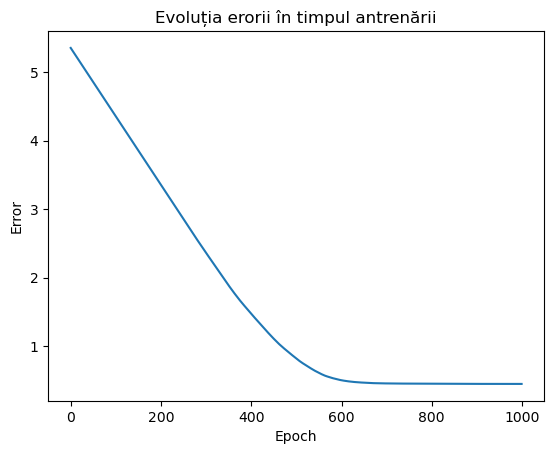

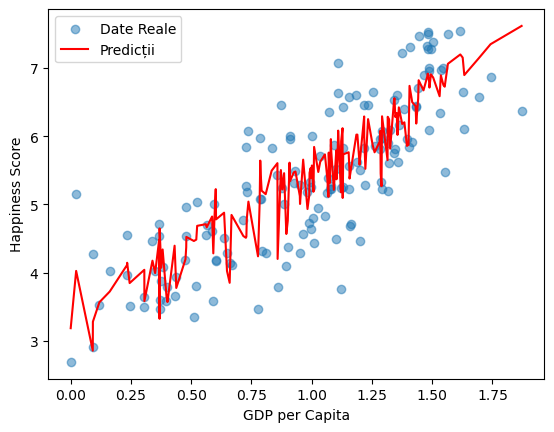

In [21]:
X_raw = df[[col_gdp, col_freedom]].values
Y = df[col_happiness].values

X_norm, media_x, std_x = normalizeaza_multi(X_raw)

W, istoric_eroare = antreneaza_batch_gd_universal(X_norm, Y, usa_mae=True)

print(f"Rezultat final: W = {W}")

plt.plot(istoric_eroare)
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.title("Evoluția erorii în timpul antrenării")
plt.show()

plt.scatter(X_raw[:, 0], Y, alpha=0.5, label="Date Reale")
Y_final_pred = W[0] + W[1] * X_norm[:, 0] + W[2] * X_norm[:, 1]
sorted_idx = np.argsort(X_raw[:, 0])
plt.plot(X_raw[sorted_idx, 0], Y_final_pred[sorted_idx], color="red", label="Predicții")
plt.xlabel("GDP per Capita")
plt.ylabel("Happiness Score")
plt.legend()
plt.show()

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X_tool = X_raw.reshape(-1, 2) if len(X_raw.shape) > 1 else X_raw.reshape(-1, 1)

model = LinearRegression()
model.fit(X_tool, Y)
Y_pred_tool = model.predict(X_tool)

mse_tool = mean_squared_error(Y, Y_pred_tool)

print("MSE:", mse_tool)


MSE: 0.32507060604542887


In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def antreneaza_logistic_batch_gd(X, Y, learning_rate=0.1, epoci=2000):
    n, m = X.shape
    X_bias = np.column_stack((X, np.ones(n)))
    W = np.zeros(m + 1)
    istoric_eroare = []

    for epoch in range(epoci):
        Z = np.dot(X_bias, W)
        Y_pred = sigmoid(Z)
        epsilon = 1e-15
        loss = -np.mean(Y * np.log(Y_pred + epsilon) + (1 - Y) * np.log(1 - Y_pred + epsilon))
        istoric_eroare.append(loss)

        gradient = (1 / n) * np.dot(X_bias.T, (Y_pred - Y))
        W -= learning_rate * gradient

    return W, istoric_eroare

In [6]:

nume_coloane = ['ID', 'Diagnostic', 'Raza', 'Textura']

df_cancer = pd.read_csv('resources/wdbc.csv', header=None, names=nume_coloane, usecols = [0, 1, 2, 3])
df_cancer['Diagnostic'] = df_cancer['Diagnostic'].map({'M': 1, 'B': 0})

X_cancer_raw = df_cancer[['Raza', 'Textura']].values
Y_cancer = df_cancer['Diagnostic'].values

X_cancer_norm, media_x_cancer, std_x_cancer = normalizeaza_multi(X_cancer_raw)
Y_cancer = df_cancer['Diagnostic'].values

W_cancer, istoric_eroare_cancer = antreneaza_logistic_batch_gd(X_cancer_norm, Y_cancer)
print(f"Results: {W_cancer}")

raza_noua = 18
textura_noua = 10
raza_norm = (raza_noua - media_x_cancer[0]) / std_x_cancer[0]
textura_norm = (textura_noua - media_x_cancer[1]) / std_x_cancer[1]

X_nou = W_cancer[0] * raza_norm + W_cancer[1] * textura_norm + W_cancer[2]
probabilitate = sigmoid(X_nou)

verdict = "Maligna" if probabilitate >= 0.5 else "Benigna"

print(f"Verdict: {verdict}, Probabilitate: {probabilitate}")

Results: [ 3.63374962  0.92549204 -0.70566962]
Verdict: Maligna, Probabilitate: 0.784216847562312


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

log_reg = LogisticRegression()
log_reg.fit(X_cancer_raw, Y_cancer)

pacienta_noua = [[18, 10]]
verdict_tool = log_reg.predict(pacienta_noua)
probabilitate_tool = log_reg.predict_proba(pacienta_noua)

print(f"Verdict tool: {'Malign' if verdict_tool[0] == 1 else 'Benign'}")
print(f"Probabilitate tool: {probabilitate_tool[0][1]}")

Verdict tool: Malign
Probabilitate tool: 0.7908768927298522


In [8]:
nume_col_iris = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'specie']
df_iris = pd.read_csv('resources/iris.csv', header=None, names=nume_col_iris)

X_iris_raw = df_iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values
Y_iris = df_iris['specie'].values

X_iris_norm, media_x_iris, std_x_iris = normalizeaza_multi(X_iris_raw)
specii_unice = np.unique(Y_iris)

In [9]:
modele_iris = {}
for specie in specii_unice:
    Y_binar = np.where(Y_iris == specie, 1, 0)
    W, _ = antreneaza_logistic_batch_gd(X_iris_norm, Y_binar)
    modele_iris[specie] = W

In [10]:
floare_test = np.array([5.35, 3.85, 1.25, 0.4])

floare_test_norm = (floare_test - media_x_iris) / std_x_iris
X_test = np.column_stack((floare_test_norm, np.ones(floare_test_norm.shape[0])))

predictions = {}
for specie, W in modele_iris.items():
    z = np.dot(floare_test_norm, W[:4]) + W[4]
    predictions[specie] = sigmoid(z)

verdict = max(predictions, key=predictions.get)
print(f"Verdict: {verdict}, Probabilitate: {predictions[verdict]}")


Verdict: Iris-setosa, Probabilitate: 0.9996060984182056


In [11]:
iris_model = LogisticRegression(max_iter= 1000)
iris_model.fit(X_iris_raw, Y_iris)

floare_test = [[5.35, 3.85, 1.25, 0.4]]
specie_tool = iris_model.predict(floare_test)

print(f"Specie tool: {specie_tool[0]}")

Specie tool: Iris-setosa


In [14]:
def impartire_date(X, Y, procent_test=0.2):
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)

    limita = int(X.shape[0] * (1 - procent_test))
    idx_train = indices[:limita]
    idx_test = indices[limita:]
    return X[idx_train], Y[idx_train], X[idx_test], Y[idx_test]

X_train, Y_train, X_test, Y_test = impartire_date(X_norm, Y)
W_final, istoric = antreneaza_batch_gd_universal(X_train, Y_train, learning_rate=0.1)
X_test_bias = np.column_stack((np.ones(X_test.shape[0]), X_test))
Y_pred_test = np.dot(X_test_bias, W_final)

mse_test = np.mean((Y_pred_test - Y_test) ** 2)
print(f"MSE Antrenament: {istoric[-1]}")
print(f"MSE Test: {mse_test}")

Epoch 0, MSE: 29.17959644213146
Epoch 100, MSE: 0.3530213515846804
Epoch 200, MSE: 0.35302135158378645
Epoch 300, MSE: 0.3530213515837865
Epoch 400, MSE: 0.3530213515837865
Epoch 500, MSE: 0.3530213515837865
Epoch 600, MSE: 0.3530213515837865
Epoch 700, MSE: 0.3530213515837865
Epoch 800, MSE: 0.3530213515837865
Epoch 900, MSE: 0.3530213515837865
MSE Antrenament: 0.3530213515837865
MSE Test: 0.21827873572356496


In [ ]:
def evalueaza_prag(W, X_test, Y_test, prag):
    X_test_bias = np.column_stack((np.ones(X_test.shape[0]), X_test))

    probabilitati = sigmoid(np.dot(X_test_bias, W))
    predictii = (probabilitati >= prag).astype(int)

    acuratete = np.mean(predictii == Y_test)
    fals_negativ = np.sum((predictii == 0) & (Y_test == 1))
    return acuratete, fals_negativ

for p in [0.2, 0.5, 0.8]:
    acc, fn = evalueaza_prag(W_cancer, X_cancer_norm, Y_cancer, p)
    print(f"Prag: {p}, Acuratete: {acc}, Cancere ratate: {fn}")



Prag: 0.2, Acuratete: 0.37258347978910367, Cancere ratate: 0
Prag: 0.5, Acuratete: 0.37258347978910367, Cancere ratate: 0
Prag: 0.8, Acuratete: 0.3866432337434095, Cancere ratate: 1
